In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
from sklearn.metrics import balanced_accuracy_score

cuda


 
- Arrowhead Beach: 36.236102, -76.695387 (Planet 4)

- Cannon's Ferry: 36.271557, -76.672967 (Planet 6)

- Rocky Hock: 36.183649, -76.719210 (Planet 3)

- Chowan River Bridge: 36.055233, -76.686425 (Planet 5)

- Point Comfort: 36.169458, -76.751827 (Planet 1)

- Mt. Gould : 36.123866, -76.742630 (Planet 2)

In [2]:
pos_only, neg_only = [],[]
for root, dirs, files in os.walk('/work/srs108/nc'):
    for file in files:
        if file == ".DS_Store":
            continue  # Skip system files
        file_path = os.path.join(root, file)
#         print(file_path)
        folder_name = os.path.basename(root)
        if folder_name == "positive":
            pos_only.append(file_path)
        elif folder_name == "negative":
            neg_only.append(file_path)
print(len(pos_only), len(neg_only))            

328 7081


In [3]:
markers = set()
# planet_paths = []
sentinel_paths = {}
lbl_dir = '/work/srs108/all_data/'

for folder in sorted(os.listdir(lbl_dir)):
    if folder not in [".DS_Store", ".ipynb_checkpoints"]:
        folder_path = os.path.join(lbl_dir, folder)
        for file in sorted(os.listdir(folder_path)):
            if file.endswith('.tif'):
                parts = file.split('.')
                name = parts[-3] 
                marker = parts[1][:4] + parts[2]  
#                 print(name, marker)
#                 if marker in markers and name == 'truecolor':
                if marker not in sentinel_paths and name == 'truecolor': 
                    sentinel_paths[marker] = os.path.join(folder_path, file)

sentinel_paths = {
    date: path
    for date, path in sentinel_paths.items()
    if date not in {'20171020', '20171021'}
}

In [4]:
site_coords = {
    "arrowhead_beach": (36.236724, -76.698134),
    "cannons_ferry": (36.272006, -76.675842),
    "chown_river": (36.055163, -76.690760),
    "mt_gould": (36.125495, -76.740141),
    "point_comfort": (36.169908, -76.745905),
    "rocky_hock_lane": (36.184133, -76.722858)
}

# Code

In [5]:
class SentinelCropDataset(Dataset):
    def __init__(self, pos_only, neg_only, sentinel_paths, site_coords, crop_size=2.5, transform=None):
        self.crop_size = crop_size
        self.transform = transform
        self.samples = []

        def extract_info(path):
            filename = os.path.basename(path)
            date = filename.split('_')[0]         # e.g., '20170626'
            site = path.split('/')[-3]            # assumes structure .../<site>/<positive|negative>/...
            return date, site

        # Helper to add sample if valid
        def maybe_add_sample(date, site, class_label):
            if date in sentinel_paths and site in site_coords:
                self.samples.append({
                    'site': site,
                    'date': date,
                    'sentinel_path': sentinel_paths[date],
                    'coord': site_coords[site],
                    'class': class_label
                })

        # Add positives (class = 1)
        for path in pos_only:
            date, site = extract_info(path)
            maybe_add_sample(date, site, class_label=1)

        for path in neg_only:
            date, site = extract_info(path)
            maybe_add_sample(date, site, class_label=0)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        file_path = sample['sentinel_path']
        lat, lon = sample['coord']

        with rio.open(file_path) as rds:
            transformer = Transformer.from_crs("EPSG:4326", rds.crs, always_xy=True)
            xx, yy = transformer.transform(lon, lat)
            row, col = rds.index(xx, yy)

            row_start = max(int(row - self.crop_size), 0)
            row_end = min(int(row + self.crop_size), rds.height)
            col_start = max(int(col - self.crop_size), 0)
            col_end = min(int(col + self.crop_size), rds.width)

            window = Window.from_slices((row_start, row_end), (col_start, col_end))
            data = rds.read([1, 2, 3], window=window).astype(np.float32) / 255.0
            image = torch.from_numpy(data)
            
        transform  = transforms.Compose([
                            transforms.ToPILImage(),
                            transforms.RandomHorizontalFlip(),
                            transforms.RandomRotation(degrees=90),
#                             transforms.CenterCrop(size=224),
                            transforms.ToTensor()
            ])
        

        output = {
            'img':transform(image),
            'lbl': sample['class'],
            'date': sample['date'],
            'site': sample['site']
        }
        return output


In [6]:
dataset = SentinelCropDataset(pos_only, neg_only, sentinel_paths, site_coords)

val_ratio, test_ratio = 0.25, 0.25
dataset_size = len(dataset)
indices = list(range(dataset_size))
batch_size = 16

train_indices, temp_indices = train_test_split(indices, test_size=(val_ratio + test_ratio), shuffle=True)
val_indices, test_indices = train_test_split(temp_indices, test_size=test_ratio/(val_ratio + test_ratio))
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)
print(len(train_dataset), len(val_dataset), len(test_dataset))

2961 1481 1481


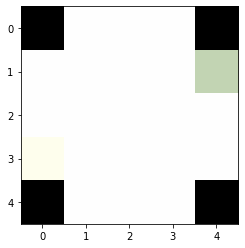

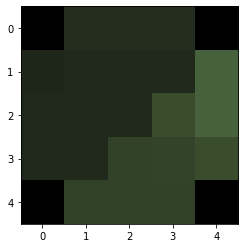

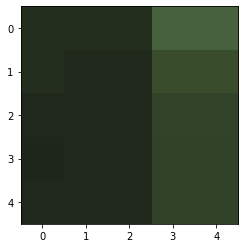

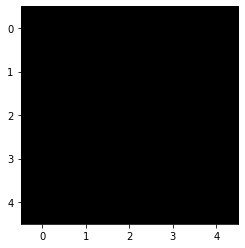

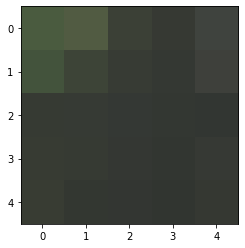

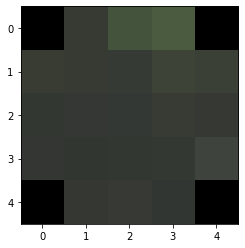

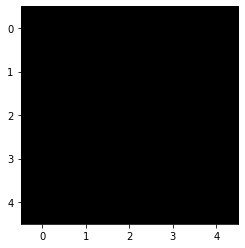

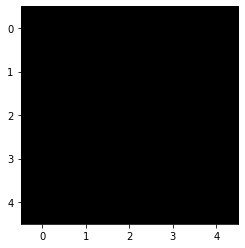

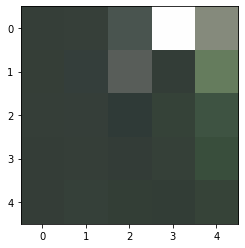

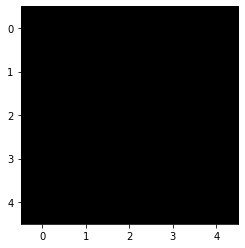

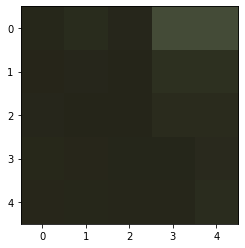

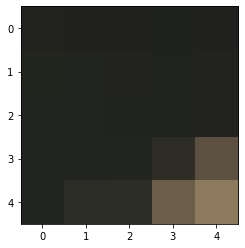

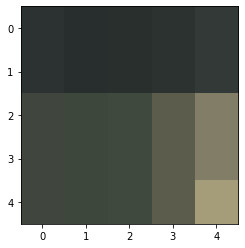

KeyboardInterrupt: 

<Figure size 432x288 with 0 Axes>

In [7]:
for i in range(len(dataset)):
    plt.imshow(dataset[i]['img'].T)
    plt.show()

In [14]:
# all_labels = [train_dataset[i]['lbl'] for i in tqdm(range(len(train_dataset)))]
# class_counts = np.bincount(all_labels)
# class_weights = 1.0 / class_counts 
# sample_weights = [class_weights[label] for label in all_labels]
# sample_weights = torch.tensor(sample_weights, dtype=torch.float)
# print(class_counts)

In [8]:
# torch.save((class_counts, class_weights, sample_weights), 'rerun_weights.pth')
class_counts, class_weights, sample_weights = torch.load('rerun_weights.pth')

In [9]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,drop_last = True)

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet_pretrained = resnet50(pretrained=True)
        self.resnet_pretrained.conv1 = nn.Conv2d(3, 64, kernel_size=(3, 3),
                              stride=(2, 2),padding=(3, 3), bias=False)
        
        self.fc1 = nn.Linear(self.resnet_pretrained.fc.out_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)  # output size changed to 2
        self.dropout = nn.Dropout(p=0.35)
    def forward(self, image):
        img_features = self.resnet_pretrained(image)
        img_features = torch.flatten(img_features, 1)
        img_features = self.fc1(img_features)
        x = self.relu(img_features)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x


In [11]:
def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0
    running_acc = 0
    running_bacc = 0
    with torch.no_grad():
        for i, batch in tqdm(enumerate(dataloader)):
            x = batch['img'].float().to(device)
            y = batch['lbl'].float().to(device)
            output = model(x).squeeze(dim=1)
                    
            output_binary = np.zeros(output.shape)
            output_binary[output.cpu().detach().numpy() >= 0] = 1
#             print(output_binary)
            loss = criterion(output,y)
            running_loss += loss.item()
            
            #accuracy
            label = y.cpu().detach().numpy()
            acc = accuracy_score(label,output_binary)
            bacc = balanced_accuracy_score(label, output_binary)
            running_acc += acc
            running_bacc += bacc

            torch.cuda.empty_cache()
        return running_loss/len(dataloader), running_acc/len(dataloader), running_bacc/len(dataloader)
            

In [12]:
def train(model, dataloader, criterion, opt, epoch, device):
    running_acc = 0
    running_loss = 0
    running_bacc = 0
    model.train()

    for i, batch in tqdm(enumerate(dataloader)):
        x = batch['img'].float().to(device)
        y = batch['lbl'].float().to(device) 
        output = model(x).squeeze(dim=1) #outputs logits (outputs before activation)
        print((output.cpu().detach().numpy()).astype(int))
        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1 #if logit is greater than 0, classify as bloom
        #loss
#         print(output_binary)
        loss = criterion(output,y) #BCEwL
        running_loss += loss.item()
        
        #accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label,output_binary)
        bacc = balanced_accuracy_score(label, output_binary)
        running_acc += acc
        running_bacc += bacc

        opt.zero_grad()
        loss.backward()
        opt.step()
        torch.cuda.empty_cache()
        
    return running_loss/len(dataloader), running_acc/len(dataloader),running_bacc/len(dataloader)

In [13]:
def main(model, epochs):
    opt                        = optim.Adam(model.parameters(), lr=1e-5)#, momentum=0.9)
    criterion                  = nn.BCEWithLogitsLoss().to(device)  
    best_loss                 = 1e6
    patience                   = np.ceil(0.1*epochs)
    trigger_times              = 0
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'train_bacc': [], 'val_bacc': []
    }

    for epoch in range(1, epochs+1):

        train_loss, train_acc, train_bacc = train(model,  train_loader, criterion, opt, epoch, device)
        val_loss, val_acc, val_bacc = test(model, val_loader, criterion, device)

        if epoch > 1:
            if val_loss < best_loss:
                trigger_times = 0
                best_loss = val_loss
                best_model_weights = model.state_dict()
                torch.save(model.state_dict(), 'rr.pt')

            else:
                trigger_times += 1
                if trigger_times == patience:
                    print(f"Early stopping on epoch {epoch} - patience reached")
                    torch.save(model.state_dict(), 'rerun_weights.pt')
                    break

        print(f'Epoch {epoch}\n\tTrain/Val Loss: {round(train_loss, 5)}/{round(val_loss, 5)}')
        print(f'\tTrain/Val Accuracy: {round(train_acc, 5)}/{round(val_acc, 5)}')
        print(f'\tTrain/Val Balanced Accuracy: {round(train_bacc, 5)}/{round(val_bacc, 5)}')

        if trigger_times != 0:
            print(f'\tCurrent Triggers: {trigger_times}')

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['train_bacc'].append(train_bacc)
        history['val_bacc'].append(val_bacc)
        df = pd.DataFrame(history)
        df.to_csv('rerun.csv', index=False)

In [14]:
model = CNN().to(device)
# model.load_state_dict(torch.load('/datacommons/carlsonlab/srs108/weak/binary/binary.pt'))
main(epochs=100, model=model)
# %time

1it [00:00,  1.61it/s]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


2it [00:00,  2.53it/s]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


3it [00:01,  3.05it/s]

...

66it [00:17,  4.02it/s]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


67it [00:18,  3.68it/s]

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


KeyboardInterrupt: 

# Post Run
## Plots

In [83]:
df = pd.read_csv('rerun.csv')

In [84]:
trl = min(df['train_loss'])
vl = min(df['val_loss'])
tra = max(df['train_acc'])
va = max(df['val_acc'])

In [85]:
print(f'Training Accuracy: {tra}\nValidation Accuracy: {va}\nTraining Loss: {trl}\nValidation Loss: {vl}')

Training Accuracy: 0.9711021505376344
Validation Accuracy: 0.9584826762246116
Training Loss: 0.0990274483688496
Validation Loss: 0.1511221744660889


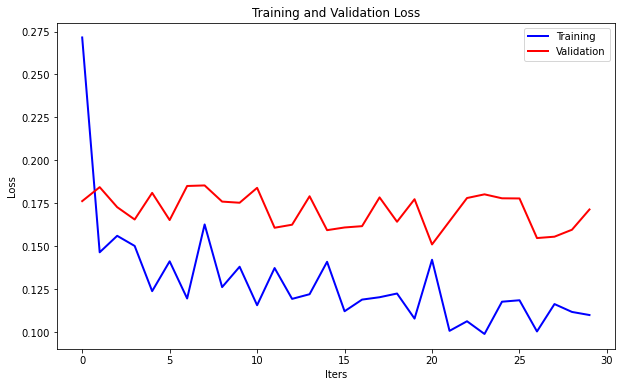

In [86]:
train_val_loss(df['train_loss'], df['val_loss'], len(df['epoch']), save=True, fig_name = 'rerunloss')

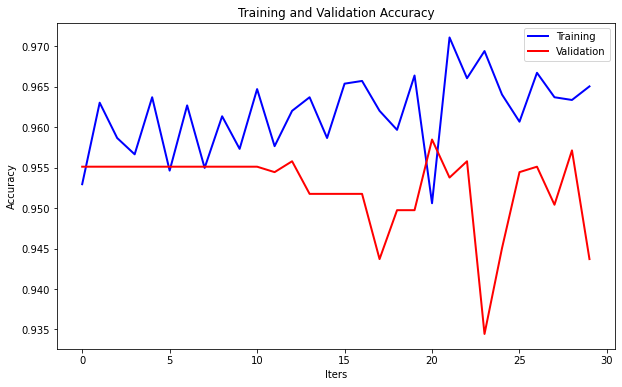

In [87]:
train_val_acc(df['train_acc'], df['val_acc'], len(df['epoch']), save=True , fig_name = 'rerunloss')

## Testing

In [88]:
model = CNN().to(device)
model.load_state_dict(torch.load('rerun_weights.pt'))
criterion = nn.BCEWithLogitsLoss().to(device)  

In [89]:
from sklearn.metrics import balanced_accuracy_score

In [90]:
model.eval()
running_loss = 0
running_acc = 0
running_bacc = 0

all_labels_for_auc = []
all_outputs_for_auc = []

all_binary_for_cm = []
all_labels_for_cm = []
all_outputs_for_cm = []

with torch.no_grad():
    for i, batch in tqdm(enumerate(test_loader)):
        x = batch['img'].float().to(device)
        y = batch['lbl'].float().to(device) 
        output =  model(x).squeeze(dim=1)
#         print()

        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1

        loss = criterion(output, y)
        running_loss += loss.item()

        all_labels_for_auc.append(y.cpu().detach().numpy())
        all_outputs_for_auc.append(output.cpu().detach().numpy())
        
        all_labels_for_cm.extend(y.cpu().detach().numpy().tolist())  # Append only values
        all_outputs_for_cm.extend(output.cpu().detach().numpy().tolist())  # Append only values
        all_binary_for_cm.extend(output_binary.tolist()) 

        # accuracy
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label, output_binary)
        running_acc += acc
        bacc = balanced_accuracy_score(label, output_binary)
        running_bacc += bacc
       
#         bloom_image_plotting(batch, output_binary,y,c)
        torch.cuda.empty_cache()
# AUC
all_labels_for_auc = np.concatenate(all_labels_for_auc)
all_outputs_for_auc = np.concatenate(all_outputs_for_auc)
auc = roc_auc_score(all_labels_for_auc, all_outputs_for_auc)
fpr, tpr, thresholds = roc_curve(all_labels_for_auc, all_outputs_for_auc)

92it [00:24,  3.70it/s]


In [91]:
rs = {'tpr':tpr,'fpr':fpr, 'auc':auc}

In [92]:
df = pd.DataFrame(rs)
df.to_csv('rs.csv', index=False)

In [93]:
def plot_roc_curve(fpr, tpr, auc, save=False):
    fig, ax = plt.subplots(1,1)
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#     plt.xlim([0.0, 1.0])
#     plt.ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize = 14)
    ax.set_ylabel('True Positive Rate', fontsize = 14)
    ax.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax.legend(loc="lower right")
    plt.show()
    if save ==True:
        fig.savefig('ROC' + '.png', transparent=False, facecolor = 'white')

0.7938449185817658
Testing Accuracy 0.9320652173913043
Testing Loss 0.22088308242129404


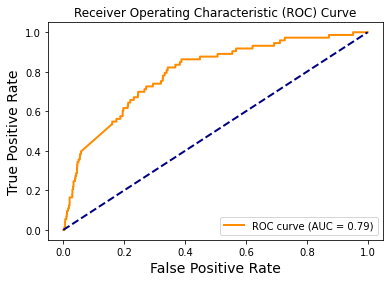

In [94]:
print(auc)

print('Testing Accuracy',running_acc/len(test_loader))
print('Testing Loss',running_loss/len(test_loader))

plot_roc_curve(fpr, tpr, auc, save=False)

In [42]:
cm = confusion_matrix(all_labels_for_cm, all_binary_for_cm)

plt.figure(figsize=(6, 4))  # Adjust the figure size as needed
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',
            xticklabels=['no bloom', 'bloom'],
            yticklabels=['no bloom', 'bloom'])

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight',facecolor='white')  # Adjust dpi and bbox_inches as needed
plt.close() 

In [43]:
running_bacc/len(test_loader)

0.8019260630673676

<Axes: >

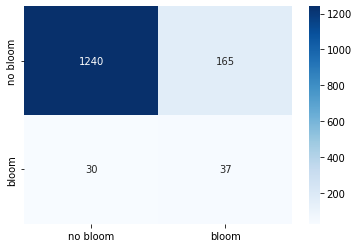

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(all_labels_for_cm, all_binary_for_cm)
sns.heatmap(cm,annot=True,cmap='Blues', fmt='g',xticklabels=['no bloom', 'bloom'], 
            yticklabels=['no bloom', 'bloom'])